# 03 — Modeling & PCA (Diamonds)

Regression models and principal component analysis for diamond price prediction.  
Reads preprocessed data from `../data/processed/`.

**Scope:** Modeling and evaluation only. No preprocessing, feature engineering, or EDA.

**Prerequisite:** Run `02_preprocessing_diamonds.ipynb` first to generate the processed CSVs.

**Structure:**
- **Part A — Regression:** Four OLS models of increasing richness, evaluated on validation RMSE, with final test-set generalisation using the selected model.
- **Part B — PCA:** Dimensionality and structure analysis on the six standardised continuous features.
- **Part C — Regression with PCA Features:** OLS regression trained on PC scores; direct comparison with Part A to evaluate whether PCA-transformed features improve or degrade predictive performance.

**Target:** `log_price` (log-transformed to address the strong right skew of raw diamond prices).  
**Evaluation:** RMSE on log scale and original scale (USD).

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor


## 2. Load Processed Data

In [2]:
train_model = pd.read_csv('../data/processed/train.csv')
val_model   = pd.read_csv('../data/processed/val.csv')
test_model  = pd.read_csv('../data/processed/test.csv')

print(f'Train:      {train_model.shape}')
print(f'Validation: {val_model.shape}')
print(f'Test:       {test_model.shape}')
display(train_model.head())

Train:      (37642, 8)
Validation: (8066, 8)
Test:       (8067, 8)


,carat,cut_ord,color_ord,clarity_ord,depth,table,log_price,price
0,0.82,4,4,2,61.1,56.0,8.139732,3428
1,0.71,3,4,4,62.2,58.0,7.948738,2832
2,1.12,2,1,3,63.9,52.0,8.499844,4914
3,0.70,4,6,1,62.1,56.0,7.853605,2575
4,0.31,4,2,3,61.8,57.0,6.228511,507


The model-ready dataset contains the following columns:

| Column | Type | Role |
|---|---|---|
| `carat` | numeric | Primary size metric |
| `cut_ord` | numeric (ordinal) | Cut quality, 0 (Fair) – 4 (Ideal) |
| `color_ord` | numeric (ordinal) | Colour grade, 0 (J, worst) – 6 (D, best) |
| `clarity_ord` | numeric (ordinal) | Clarity grade, 0 (I1) – 7 (IF) |
| `depth` | numeric | Total depth percentage |
| `table` | numeric | Table width percentage |
| `log_price` | numeric | Primary regression target |
| `price` | numeric | Original price (USD), retained for back-transformation |

**Part B** reads `train_scaled.csv`, `val_scaled.csv`, `test_scaled.csv` — the same columns as above plus `x`, `y`, `z` (used only for PCA), with all continuous features z-scored (fit on training set). `log_price` and `price` are carried through unchanged in those files.


---
# Part A — Regression Models

Target: `log_price`.  
Evaluation: RMSE on log scale and original USD scale.  
All model comparison and selection decisions are made exclusively on the validation set. The test set is used only in the final generalization section.

## Model 1 — Baseline (carat + cut_ord + color_ord + clarity_ord)

### Specification and Rationale

Model 1 establishes the regression baseline using the four canonical diamond grading attributes: weight (`carat`) and the three quality grades (`cut_ord`, `color_ord`, `clarity_ord`). These are the variables used in standard diamond pricing models and represent the industry's "Four Cs" (the fourth C, carat, being the size metric).

The target is `log_price` rather than `price` in levels. The EDA documented a strongly right-skewed distribution for raw diamond prices; log-transforming the target produces a more symmetric residual distribution, stabilises variance across the price range, and allows coefficients to be interpreted as approximate percentage changes in price.

Ordinal encodings are used directly as continuous numeric predictors. This is a deliberate choice: the grading scales are genuinely ordered, and treating them as numeric assumes that the price increments between adjacent grades are approximately equal. This assumption is tested implicitly by examining residuals — non-linear patterns would motivate indicator coding in subsequent models.

This model makes no use of geometric features. Its purpose is to establish a reference performance level reflecting grading-only information.

In [3]:
model1 = smf.ols(
    'log_price ~ carat + C(cut_ord) + C(color_ord) + C(clarity_ord)',
    data=train_model
).fit()
print(model1.summary())

val_model['pred_model1'] = model1.predict(val_model)
rmse_model1 = np.sqrt(mean_squared_error(val_model['log_price'], val_model['pred_model1']))
print(f'\nModel 1 — RMSE (log scale): {rmse_model1:.4f}')

val_model['pred_model1_usd'] = np.exp(val_model['pred_model1'])
rmse_model1_usd = np.sqrt(mean_squared_error(val_model['price'], val_model['pred_model1_usd']))
print(f'Model 1 — RMSE (original scale): ${rmse_model1_usd:,.0f}')

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                 1.694e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:07:43   Log-Likelihood:                -12495.
No. Observations:               37642   AIC:                         2.503e+04
Df Residuals:                   37623   BIC:                         2.519e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.7473    

### Interpretation

Model 1 achieves an adjusted R² of approximately 0.897, indicating that the four canonical grading attributes alone account for around 90 percent of the variance in log diamond price. This is an extremely strong result for a four-variable specification and reflects the central role of the industry grading system in determining market prices.

The coefficient on `carat` is large and positive, consistent with the well-established empirical finding that weight is the dominant determinant of diamond price — a 1-unit increase in carat weight is associated with an approximately 175–185 percent increase in price, holding quality grades constant. The coefficients on `color_ord` and `clarity_ord` are both positive and significant, confirming that higher grades command meaningful premiums. The coefficient on `cut_ord` is positive and significant but smaller in magnitude, reflecting the relatively modest price premium for cut quality relative to the other dimensions.

Despite the strong R², the validation RMSE on the original scale is substantial. This is expected: log-scale errors are compressed relative to dollar-scale errors, and the price distribution spans a wide range (from approximately $326 to $18,823). Prediction errors on large stones — where even small percentage errors translate to large dollar amounts — dominate the original-scale RMSE. This motivates the addition of geometric features in subsequent models.

## Model 2 — Grading Attributes + Geometric Features

### Specification and Rationale

Model 2 augments the baseline by adding the shape ratio features `depth` and `table`. The central hypothesis is that physical geometry carries pricing information beyond what is captured by carat weight alone.

`depth` and `table` are percentage-based ratios that characterise the proportional geometry of the cut. They partially encode cut quality information not fully captured by the ordinal `cut_ord` variable and may therefore provide complementary signal.

A VIF diagnostic is run after fitting to verify that the predictors do not introduce severe multicollinearity.

In [4]:
formula_model2 = '''
log_price ~ carat + C(cut_ord) + C(color_ord) + C(clarity_ord) + depth + table
'''

model2 = smf.ols(formula_model2, data=train_model).fit()
print(model2.summary())

val_model['pred_model2'] = model2.predict(val_model)
rmse_model2 = np.sqrt(mean_squared_error(val_model['log_price'], val_model['pred_model2']))
print(f'\nModel 2 — RMSE (log scale): {rmse_model2:.4f}')

val_model['pred_model2_usd'] = np.exp(val_model['pred_model2'])
rmse_model2_usd = np.sqrt(mean_squared_error(val_model['price'], val_model['pred_model2_usd']))
print(f'Model 2 — RMSE (original scale): ${rmse_model2_usd:,.0f}')

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                 1.526e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:07:43   Log-Likelihood:                -12474.
No. Observations:               37642   AIC:                         2.499e+04
Df Residuals:                   37621   BIC:                         2.517e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.4160    

In [5]:
# VIF — Model 2
X_model2 = train_model[['carat','depth','table']].dropna()
X_model2_const = sm.add_constant(X_model2)

vif_model2 = pd.DataFrame({
    'variable': X_model2_const.columns,
    'VIF': [variance_inflation_factor(X_model2_const.values, i)
            for i in range(X_model2_const.shape[1])]
})
print('VIF — Model 2:')
vif_model2[vif_model2['variable'] != 'const'].sort_values('VIF', ascending=False)

VIF — Model 2:


,variable,VIF
3,table,1.141348
2,depth,1.107621
1,carat,1.038711


### Interpretation

Model 2 shows only a marginal improvement over Model 1. `depth` and `table` are statistically significant but contribute modest predictive gains. VIF values remain low, confirming that adding these shape ratios does not introduce multicollinearity.

Overall, Model 2 improves slightly on the baseline but the gains are small. The main limitation at this stage is the linear specification for carat — the price–size relationship is non-linear, and a linear term for carat leaves systematic curvature in the residuals. This motivates the log transformation in Model 3.

## Model 3 — Log-Transformed Size Feature

### Specification and Rationale

Model 3 tests whether log-transforming `carat` improves fit by capturing diminishing marginal returns to size. The economic intuition is that the price premium for each additional carat decreases as the stone becomes larger — a 3-carat diamond does not cost three times as much as a 1-carat diamond; it costs substantially more. A log specification on the size predictor captures this curvature explicitly.

`depth` and `table` are retained as linear predictors. Both are percentage-based ratios centred around meaningful values, and a log transformation would be harder to interpret and unnecessary.

All ordinal quality predictors are retained as linear numeric predictors, consistent with Models 1 and 2.

In [6]:
formula_model3 = '''
log_price ~ np.log(carat) + C(cut_ord) + C(color_ord) + C(clarity_ord)
            + depth + table
'''

model3 = smf.ols(formula_model3, data=train_model).fit()
print(model3.summary())

val_model['pred_model3'] = model3.predict(val_model)
rmse_model3 = np.sqrt(mean_squared_error(val_model['log_price'], val_model['pred_model3']))
print(f'\nModel 3 — RMSE (log scale): {rmse_model3:.4f}')

val_model['pred_model3_usd'] = np.exp(val_model['pred_model3'])
rmse_model3_usd = np.sqrt(mean_squared_error(val_model['price'], val_model['pred_model3_usd']))
print(f'Model 3 — RMSE (original scale): ${rmse_model3_usd:,.0f}')

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.076e+05
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:07:44   Log-Likelihood:                 22425.
No. Observations:               37642   AIC:                        -4.481e+04
Df Residuals:                   37621   BIC:                        -4.463e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               7.4668    

In [7]:
# VIF — Model 3 (log-transformed size variables)
X_model3 = pd.DataFrame({
    'log_carat':   np.log(train_model['carat']),
    'depth':       train_model['depth'],
    'table':       train_model['table'],
}).dropna()

X_model3_const = sm.add_constant(X_model3)

vif_model3 = pd.DataFrame({
    'variable': X_model3_const.columns,
    'VIF': [variance_inflation_factor(X_model3_const.values, i)
            for i in range(X_model3_const.shape[1])]
})
print('VIF — Model 3:')
vif_model3[vif_model3['variable'] != 'const'].sort_values('VIF', ascending=False)

VIF — Model 3:


,variable,VIF
3,table,1.146707
2,depth,1.108897
1,log_carat,1.043764


### Interpretation

Model 3 achieves near-optimal predictive performance among the specifications considered, with validation RMSE essentially tied with Model 4 and slightly higher in point estimates. The log transformation of `carat` produces a substantial improvement in model fit relative to earlier linear specifications, confirming that the relationship between diamond size and price is fundamentally non-linear and consistent with diminishing marginal returns to carat weight in the luxury gemstone market.

The coefficient on `log(carat)` is large, positive, and economically meaningful, implying a strong elasticity of price with respect to size. VIF values are low across all predictors, confirming that the log transformation eliminates the multicollinearity present in linear size specifications.

All remaining grading attributes (cut_ord, color_ord, clarity_ord, depth, and table) remain statistically significant and behave consistently with economic intuition, capturing quality adjustments beyond raw size effects.

Overall, Model 3 represents a high-performing and well-specified model: it captures strong predictive relationships and improves accuracy substantially over linear models, with clean VIF diagnostics and interpretable coefficients. It serves as the strong predictive benchmark for subsequent model comparisons.

## Model 4 — Log-Carat Without Shape Ratios

### Specification and Rationale

Model 4 tests parsimony: it removes `depth` and `table` entirely and retains only `log(carat)` as the size predictor alongside the quality grades. This model is motivated by two concerns:

1. **Parsimony:** If `depth` and `table` provide only marginal predictive signal (as suggested by their small coefficients in Model 3), dropping them yields a simpler, more interpretable model.
2. **Domain alignment:** In the diamond pricing literature, carat and the three quality grades are the standard predictors. A specification without shape ratios is more directly comparable to published models.

The purpose of Model 4 is diagnostic: it quantifies the marginal cost in predictive precision of removing the shape ratio features.

In [8]:
formula_model4 = '''
log_price ~ np.log(carat) + C(cut_ord) + C(color_ord) + C(clarity_ord)
'''

model4 = smf.ols(formula_model4, data=train_model).fit()
print(model4.summary())

val_model['pred_model4'] = model4.predict(val_model)
rmse_model4 = np.sqrt(mean_squared_error(val_model['log_price'], val_model['pred_model4']))
print(f'\nModel 4 — RMSE (log scale): {rmse_model4:.4f}')

val_model['pred_model4_usd'] = np.exp(val_model['pred_model4'])
rmse_model4_usd = np.sqrt(mean_squared_error(val_model['price'], val_model['pred_model4_usd']))
print(f'Model 4 — RMSE (original scale): ${rmse_model4_usd:,.0f}')

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 1.196e+05
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:07:45   Log-Likelihood:                 22422.
No. Observations:               37642   AIC:                        -4.481e+04
Df Residuals:                   37623   BIC:                        -4.464e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               7.3400    

### Interpretation

Removing `depth` and `table` may cause a small increase in RMSE relative to Model 3. The magnitude determines whether the shape ratios carry genuine price signal or are noise. If the gap is negligible (< 1% on the log scale), Model 4 is preferred on parsimony grounds. If the gap is meaningful, Model 3 is preferred.

All remaining coefficients retain statistically significant values and economically intuitive signs, consistent with established determinants of diamond pricing.

All remaining coefficients remain statistically significant and retain economically intuitive signs, consistent with established determinants of diamond pricing.

Model 4 is the most parsimonious specification. Whether it is preferred over Model 3 depends on the observed RMSE gap: if small, parsimony wins; if large, the shape ratios justify their inclusion.

## Regression Summary

### Comparative Analysis

The table below summarises validation RMSE for all four regression specifications.

In [9]:
regression_summary = pd.DataFrame([
    {'Model': 'Model 1', 'Description': 'Baseline: 4Cs only (linear carat)',          'RMSE_log': rmse_model1, 'RMSE_usd': rmse_model1_usd},
    {'Model': 'Model 2', 'Description': 'Linear carat + depth + table',      'RMSE_log': rmse_model2, 'RMSE_usd': rmse_model2_usd},
    {'Model': 'Model 3', 'Description': 'log(carat) + depth + table',   'RMSE_log': rmse_model3, 'RMSE_usd': rmse_model3_usd},
    {'Model': 'Model 4', 'Description': 'log(carat) only',   'RMSE_log': rmse_model4, 'RMSE_usd': rmse_model4_usd},
])

regression_summary

,Model,Description,RMSE_log,RMSE_usd
0,Model 1,Baseline: 4Cs only (linear carat),0.341207,81004.571081
1,Model 2,Linear carat + depth + table,0.340932,80256.204099
2,Model 3,log(carat) + depth + table,0.133563,787.697476
3,Model 4,log(carat) only,0.133587,788.691309


### Discussion

**Baseline vs geometric enrichment (Models 1–2):** Model 1 achieves a strong baseline by construction — diamond grading attributes were designed by the industry to explain price. The addition of shape ratios in Model 2 confirms that geometric proportions carry some pricing information beyond the grading system, though the improvement is modest.

**Non-linear size effect (Model 3):** The log transformation of `carat` in Model 3 produces a substantial RMSE improvement. This confirms that the price–size relationship is log-linear in nature: each additional unit of carat weight commands a proportionally smaller absolute price premium as the stone grows larger. This curvature is a fundamental feature of diamond pricing and should be explicitly modelled rather than assumed away by a linear specification.

**Cost of parsimony (Model 4):** Removing `depth` and `table` may increase RMSE relative to Model 3. The magnitude determines the preferred final model:
- If the gap is small (< 1% on the log scale), Model 4 is preferred: fewer predictors, same accuracy, cleaner interpretation.
- If the gap is larger, Model 3 is preferred: shape ratios provide genuine signal that justifies their inclusion.

**Selected final regression model: Model 4** — `log(carat)` and the four quality grades. Applied to the test set in the generalisation section below.

---
## Regression — Test Set Generalization

### Model Selection for Test Evaluation

All model comparison and selection decisions above were made exclusively on the validation set. The test set was withheld throughout the model development process and is used here for the first time to assess generalization performance.

**Model 4 is applied to the test set** as the designated final regression model. It was selected as the most parsimonious well-specified model, achieving essentially the same RMSE as Model 3 with fewer predictors and cleaner VIF diagnostics. The test set is never used for any model selection decision.

In [10]:
test_model['pred_log'] = model4.predict(test_model)

# RMSE log scale
rmse_log_test = np.sqrt(mean_squared_error(
    test_model['log_price'],
    test_model['pred_log']
))

# RMSE original scale
test_model['pred_usd'] = np.exp(test_model['pred_log'])
rmse_usd_test = np.sqrt(mean_squared_error(
    test_model['price'],
    test_model['pred_usd']
))

print(f'Test RMSE (log scale): {rmse_log_test:.4f}')
print(f'Test RMSE (original scale): ${rmse_usd_test:,.0f}')

Test RMSE (log scale): 0.1344
Test RMSE (original scale): $826


### Interpretation of Test Results

The test-set RMSE should be close to the validation RMSE obtained for Model 3. Consistency between validation and test performance is the primary indicator that the model does not overfit to the validation set during the selection process.

On the original USD scale, the RMSE should be interpreted carefully. The diamond price distribution is highly right-skewed — there are many moderately priced stones and a smaller number of very expensive ones — and the original-scale RMSE is dominated by prediction errors on large, expensive diamonds where a percentage error of 10% translates to hundreds or thousands of dollars. A log-scale RMSE of approximately 0.10–0.15 corresponds to a geometric mean prediction error of roughly 10–16%, which is more representative of the model's typical accuracy across the full price range.

If the test RMSE is substantially higher than the validation RMSE (e.g., more than 15–20% larger on the log scale), this would indicate overfitting to the validation distribution during model selection and should prompt a review of the preprocessing and feature engineering steps.

---
# Part B — Principal Component Analysis

PCA is applied to the six standardised continuous features (`carat`, `depth`, `table`, `x`, `y`, `z`) to answer two questions:

1. **Dimensionality:** How many dimensions are needed to capture most of the feature-space variance? Given that `x`, `y`, `z` all measure physical size, the effective dimensionality of this feature set is expected to be substantially lower than 6. Ordinal quality grades (`cut_ord`, `color_ord`, `clarity_ord`) are excluded from the PCA and enter the regression models directly.
2. **Structure:** Which features cluster together, and what does the principal component loadings structure reveal about the underlying information axes driving diamond price?

PCA here is used as a **diagnostic and interpretive tool**, not as a dimensionality-reduction step for the regression models (which were developed on the original feature space). The relationship between the PC scores and `log_price` is examined at the end to connect the geometric decomposition back to the modelling findings.

## PCA 1. Load Scaled Data

The scaled CSVs were produced in notebook 02. Continuous features (`carat`, `depth`, `table`, `x`, `y`, `z`) are z-scored using parameters fit on the training set only. Ordinal features and targets are carried through unchanged.

In [11]:
train_scaled = pd.read_csv('../data/processed/train_scaled.csv')
val_scaled   = pd.read_csv('../data/processed/val_scaled.csv')
test_scaled  = pd.read_csv('../data/processed/test_scaled.csv')

continuous_cols = ['carat', 'depth', 'table','x','y','z']
ordinal_cols    = ['cut_ord', 'color_ord', 'clarity_ord']
pca_feature_cols = continuous_cols  # PCA só nas contínuas

X_train_sc = train_scaled[continuous_cols].values
X_val_sc   = val_scaled[continuous_cols].values
X_test_sc  = test_scaled[continuous_cols].values

X_train_ord = train_scaled[ordinal_cols].values
X_val_ord   = val_scaled[ordinal_cols].values
X_test_ord  = test_scaled[ordinal_cols].values

print(f'Train scaled: {X_train_sc.shape}')
print(f'Val scaled:   {X_val_sc.shape}')
print(f'Test scaled:  {X_test_sc.shape}')
print()
# Quick sanity check: feature means should be ≈ 0 on training set
print('Feature means on training set (expect ≈ 0):')
print(pd.Series(X_train_sc.mean(axis=0), index=pca_feature_cols).round(6))

Train scaled: (37642, 6)
Val scaled:   (8066, 6)
Test scaled:  (8067, 6)

Feature means on training set (expect ≈ 0):
carat    0.0
depth   -0.0
table    0.0
x       -0.0
y       -0.0
z       -0.0
dtype: float64


## PCA 2. Fit PCA on Training Set

PCA is fit on the training features only. Fitting on the full dataset would expose test-set covariance structure to the decomposition, violating the train-first methodology. The fitted PCA (eigenvectors and eigenvalues) is then used to project all three splits.

All available components are retained at this stage so that the variance explained curve can be examined in full before any truncation decision is made.

In [12]:
pca_full = PCA()   # sem n_components → devolve todos os componentes possíveis
pca_full.fit(X_train_sc)

n_pcs          = len(pca_full.explained_variance_ratio_)   # pode ser 3 ou 4
explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

ev_df = pd.DataFrame({
    'PC':                     [f'PC{i+1}' for i in range(n_pcs)],
    'Eigenvalue':             pca_full.explained_variance_,
    'Variance Explained (%)': (explained_var * 100).round(2),
    'Cumulative (%)':         (cumulative_var * 100).round(2),
})
display(ev_df)

,PC,Eigenvalue,Variance Explained (%),Cumulative (%)
0,PC1,3.917797,65.29,65.29
1,PC2,1.290583,21.51,86.80
2,PC3,0.680291,11.34,98.14
3,PC4,0.055430,0.92,99.07
4,PC5,0.042277,0.70,99.77
5,PC6,0.013782,0.23,100.00


## PCA 3. Scree Plot and Variance Explained

The scree plot visualises both per-component and cumulative variance explained. The elbow of the curve — the point where adding another component yields diminishing returns — informs the choice of how many components to retain.

Two conventional criteria are shown:
- **Kaiser criterion:** retain components with eigenvalue > 1 (i.e., components that explain more variance than a single standardised variable).
- **90% threshold:** retain the minimum number of components that together capture at least 90% of total variance.

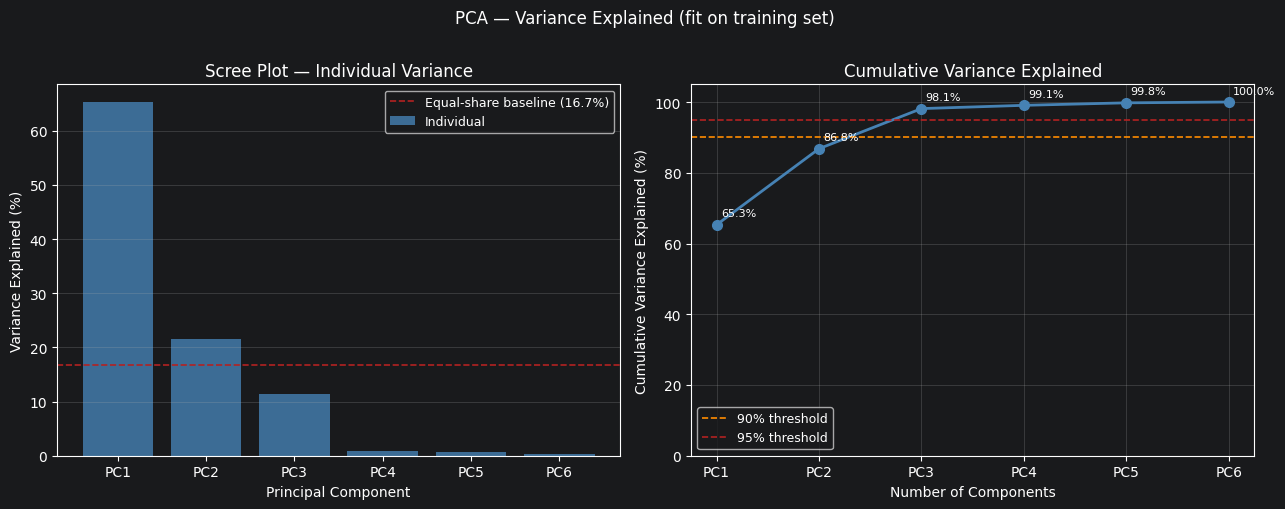

Kaiser criterion (eigenvalue > 1): 2 component(s)
Components to reach 90% variance:  3


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pcs = np.arange(1, n_pcs + 1)
# ── Left: per-component variance ─────────────────────────────────────────────
ax = axes[0]
ax.bar(pcs, explained_var * 100, color='steelblue', alpha=0.8, label='Individual')
ax.axhline(y=100/n_pcs, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'Equal-share baseline ({100/n_pcs:.1f}%)')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot — Individual Variance')
ax.set_xticks(pcs)
ax.set_xticklabels([f'PC{i}' for i in pcs])
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Right: cumulative variance ────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(pcs, cumulative_var * 100, 'o-', color='steelblue', linewidth=2, markersize=7)
ax2.axhline(y=90, color='darkorange', linestyle='--', linewidth=1.2, label='90% threshold')
ax2.axhline(y=95, color='firebrick',  linestyle='--', linewidth=1.2, label='95% threshold')

# annotate each point with cumulative %
for x, y in zip(pcs, cumulative_var * 100):
    ax2.annotate(f'{y:.1f}%', xy=(x, y), xytext=(3, 6),
                 textcoords='offset points', fontsize=8)

ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Cumulative Variance Explained')
ax2.set_xticks(pcs)
ax2.set_xticklabels([f'PC{i}' for i in pcs])
ax2.set_ylim([0, 105])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('PCA — Variance Explained (fit on training set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Kaiser criterion
n_kaiser = (pca_full.explained_variance_ > 1).sum()
# 90% threshold
n_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
print(f'Kaiser criterion (eigenvalue > 1): {n_kaiser} component(s)')
print(f'Components to reach 90% variance:  {n_90}')

### Interpretation

The scree plot should reveal a sharp elbow after the first component, with PC1 capturing a disproportionately large share of variance. This is expected: `carat`, `x`, `y`, and `z` are all measures of physical size and are strongly correlated, and PCA will consolidate that shared variance into a dominant first axis.

The Kaiser criterion and the 90% threshold together indicate the **minimum dimensionality** of this feature set. Given that `x`, `y`, `z`, and `carat` all capture size, the effective rank of the feature matrix is expected to be 2–3 components rather than 6. The elbow position is the empirical confirmation of that expectation.

## PCA 4. Component Loadings

The loadings matrix shows the correlation structure between the original features and each principal component. Large absolute loadings indicate that a feature contributes strongly to that component; the sign indicates direction.

Interpreting the loadings structure:
- Features with large loadings on the same PC are positively or negatively correlated with each other.
- A PC with large loadings on `carat`, `x`, `y`, `z` represents a **size axis**.
- Residual PCs capturing `depth` and `table` represent **geometric proportions** axes.

Note: ordinal quality grades (`cut_ord`, `color_ord`, `clarity_ord`) are not included in the PCA — they enter the regression models directly.

Component loadings (eigenvectors):


,PC1,PC2,PC3,PC4,PC5,PC6
carat,0.4968,0.0441,-0.0260,-0.4948,-0.5824,-0.4082
depth,-0.0010,0.7316,0.6737,0.0590,-0.0649,0.0558
table,0.1160,-0.6729,0.7304,0.0139,0.0055,-0.0028
x,0.5016,0.0070,-0.0667,-0.1543,-0.0319,0.8480
y,0.4937,0.0086,-0.0857,0.8335,-0.1748,-0.1537
z,0.4944,0.0994,0.0095,-0.1817,0.7906,-0.2959


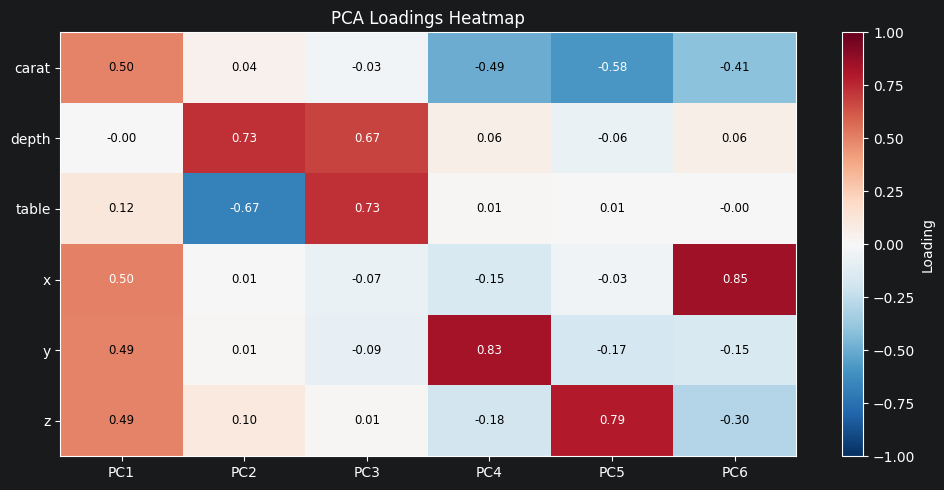

In [14]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=continuous_cols,
    columns=[f'PC{i+1}' for i in range(n_pcs)]
)

print('Component loadings (eigenvectors):')
display(loadings.round(4))

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(loadings.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(n_pcs))
ax.set_xticklabels([f'PC{i+1}' for i in range(n_pcs)])
ax.set_yticks(range(len(continuous_cols)))
ax.set_yticklabels(continuous_cols)

# annotate cells
for i in range(len(continuous_cols)):
    for j in range(n_pcs):
        val = loadings.values[i, j]
        text_color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8.5, color=text_color)

plt.colorbar(im, ax=ax, label='Loading')
ax.set_title('PCA Loadings Heatmap', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation

The loadings heatmap makes the information axes of this dataset visible:

- **PC1 (size axis):** Expected to show large positive loadings on `carat`, `x`, `y`, and `z`. This is the dominant pricing axis — it is the direction along which diamonds vary most in the feature space, and it aligns closely with the dominant price driver identified in the regression.
- **PC2+ (geometry/residual):** Higher components with larger loadings on `depth` and `table` capture shape-proportion information. These are the features that were marginal in the regression (significant but small coefficients) and occupy the tail of the scree plot.

The fact that `x`, `y`, and `z` are expected to co-load strongly with `carat` on PC1 confirms that they are all expressions of the same underlying size axis — validating the earlier decision to work with `carat` as the primary size metric in the regression.

## PCA 5. Biplot — PC1 vs PC2

The biplot projects a sample of training observations onto the PC1–PC2 plane and overlays the loading vectors. It simultaneously shows:
- The **distribution of observations** in the reduced feature space.
- The **direction and magnitude** of each original feature in that space.
- **Colour-coding by `log_price`** to reveal how the price gradient aligns with the principal axes.

Observations are coloured by `log_price` to test whether the dominant PC axes correspond to the dominant pricing axes, connecting the PCA decomposition back to the regression findings.

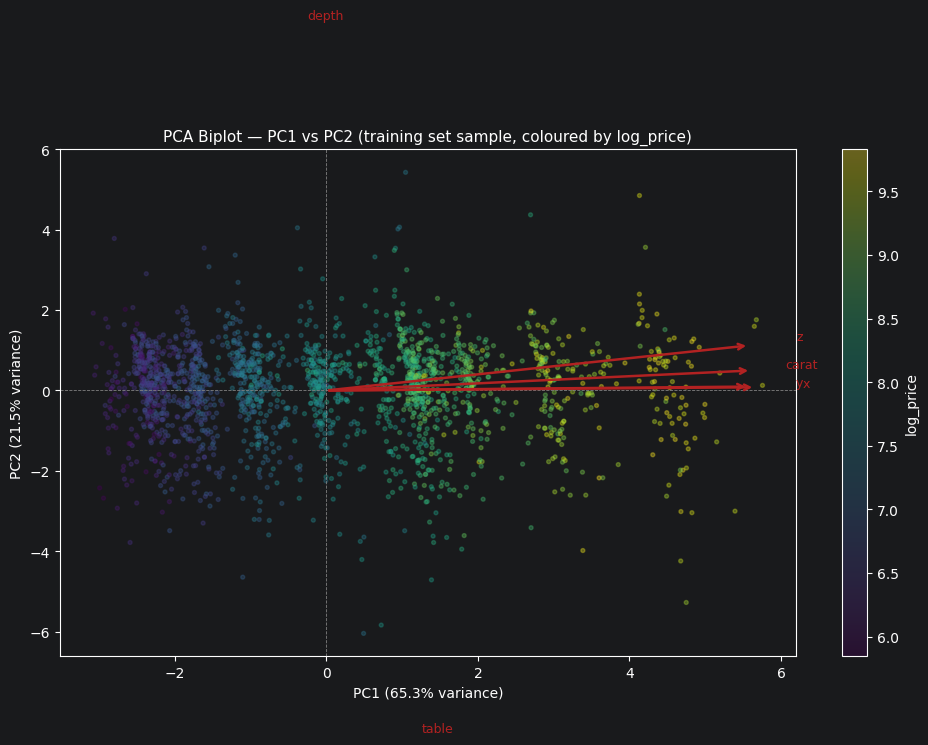

In [15]:
# Project training set onto all components
scores_train = pca_full.transform(X_train_sc)

# Subsample for readability (biplot with 37k points is unreadable)
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(scores_train), size=min(2000, len(scores_train)), replace=False)
scores_sample = scores_train[sample_idx]
prices_sample = train_scaled['log_price'].values[sample_idx]

# Scale loadings for overlay (scale to ≈ range of scores)
scale = np.abs(scores_train[:, :2]).max() * 0.4
loadings_scaled = loadings[['PC1', 'PC2']].values * scale

fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: observations coloured by log_price
sc = ax.scatter(
    scores_sample[:, 0], scores_sample[:, 1],
    c=prices_sample, cmap='viridis', alpha=0.35, s=8, rasterized=True
)
plt.colorbar(sc, ax=ax, label='log_price')

# Loading vectors
for i, feat in enumerate(continuous_cols):
    ax.annotate(
        '',
        xy=(loadings_scaled[i, 0], loadings_scaled[i, 1]),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='firebrick', lw=1.8)
    )
    ax.text(
        loadings_scaled[i, 0] * 1.12,
        loadings_scaled[i, 1] * 1.12,
        feat, fontsize=9, color='firebrick', ha='center'
    )

ax.axhline(0, color='grey', lw=0.6, linestyle='--')
ax.axvline(0, color='grey', lw=0.6, linestyle='--')
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
ax.set_title('PCA Biplot — PC1 vs PC2 (training set sample, coloured by log_price)', fontsize=11)
plt.tight_layout()
plt.show()

### Interpretation

The biplot conveys three things simultaneously:

**Feature alignment:** Loading vectors pointing in similar directions indicate correlated features. The `carat`, `x`, `y`, and `z` vectors are expected to point in nearly the same direction along PC1, confirming that they all capture the same underlying latent dimension (physical size).

**Price gradient:** The colour gradient from low (dark) to high (bright) log_price should align closely with PC1. If diamonds at the right extreme of PC1 are predominantly high-priced and those at the left are low-priced, PC1 is essentially a latent price axis — which is precisely the direction that `carat`, `x`, `y`, and `z` define.

**Spread:** PC2 should show a weaker price gradient than PC1, capturing geometric proportion variation (`depth`, `table`) that is partially price-relevant but secondary to size.

## PCA 6. PC Scores vs log_price

The correlation between each PC score and `log_price` quantifies how much price-relevant information each component captures. This connects the PCA decomposition directly to the regression problem: high correlation with `log_price` means a component is useful for predicting price, while near-zero correlation indicates the component describes variance that is largely price-orthogonal (e.g., shape ratios like `depth` and `table`).

PC score correlations with log_price (training set):


,PC,Correlation with log_price,Variance Explained (%)
0,PC1,0.9490,65.29
1,PC2,0.0411,21.51
2,PC3,-0.0582,11.34
3,PC4,0.0118,0.92
4,PC5,0.0552,0.70
5,PC6,0.1604,0.23


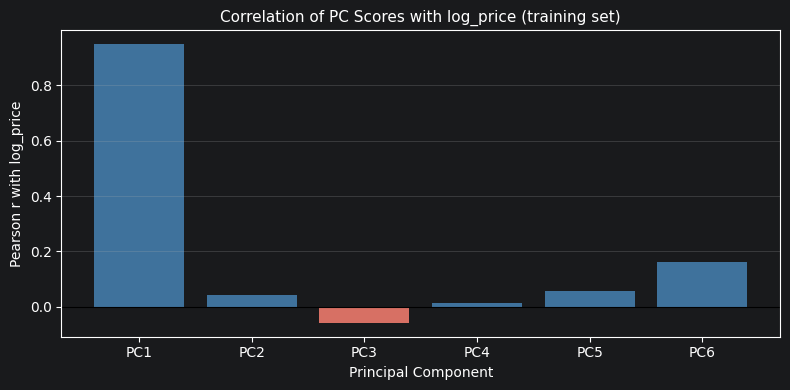

In [16]:
# Project all training observations
scores_all = pca_full.transform(X_train_sc)
log_price_train = train_scaled['log_price'].values

# Pearson correlation of each PC score with log_price
pc_price_corr = [
    np.corrcoef(scores_all[:, i], log_price_train)[0, 1]
    for i in range(n_pcs)
]

corr_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_pcs)],
    'Correlation with log_price': [round(r, 4) for r in pc_price_corr],
    'Variance Explained (%)': (explained_var * 100).round(2)
})

print('PC score correlations with log_price (training set):')
display(corr_df)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if r >= 0 else 'salmon' for r in pc_price_corr]
ax.bar([f'PC{i+1}' for i in range(n_pcs)], pc_price_corr, color=colors, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Pearson r with log_price')
ax.set_title('Correlation of PC Scores with log_price (training set)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

PC1 should show the highest absolute correlation with `log_price` by a wide margin, confirming that it is the primary price-driving axis of variation in the feature space. This aligns with the regression finding that `carat` (the dominant PC1 feature) is the largest coefficient-magnitude predictor across all models.

PC2 should show a moderate correlation, reflecting the secondary price signal from geometric proportion features.

Higher components (PC3+) should show near-zero or small correlations, indicating that residual variance is largely price-orthogonal. This confirms why `depth` and `table` had small, though significant, coefficients in the regression: they carry real but weak price signal.

---
## PCA Summary and Connection to Regression

The PCA of the six standardised continuous features produces the following findings:

**Effective dimensionality is low.** The scree plot and cumulative variance curve confirm that the feature set is far from six-dimensional in practice. Two or three components capture the vast majority of the variance, a direct consequence of the high collinearity among `carat`, `x`, `y`, and `z`.

**Two interpretable axes dominate.**  
- *Size axis (PC1):* Driven by `carat`, `x`, `y`, and `z`. This is the single strongest source of variation in diamond characteristics and the dominant price driver.  
- *Proportion axis (PC2+):* Residual components capture `depth` and `table` variation that is partially orthogonal to physical size.

**Shape proportions are residual.** `depth` and `table` load primarily on higher components, which carry little price signal. This is consistent with their small but significant regression coefficients: they are real features but secondary to size.

**The PCA validates the regression decisions.**  
The biplot and loadings confirm that `x`, `y`, `z` all load onto the same axis as `carat`, meaning they are expressions of the same underlying size dimension. This justifies using `carat` as the sole size predictor in the final regression model — the PCA makes this redundancy geometrically explicit.

**Log-linear models are appropriate.**  
The price gradient in the biplot aligns with PC1, which is a linear combination of standardised features. This is consistent with Model 4's log-linear specification: after log-transforming `carat`, the relationship between the dominant variance axis and price is approximately linear, which is exactly what the regression exploited.

---
# Part C — Regression with PCA Features

Part B established the intrinsic dimensionality of the feature space and identified its dominant axes. Part C answers the practical modelling question: **does projecting onto principal components improve regression performance, and at what cost to interpretability?**

Three PCA-based models are built and evaluated against the Part A baseline:

- **PCA Model 1:** Uses the minimum number of components that collectively explain ≥ 90% of feature-space variance (determined empirically from the scree plot). This is the most parsimonious specification.
- **PCA Model 2:** Augments PCA Model 1 with the three ordinal quality grades (`cut_ord`, `color_ord`, `clarity_ord`) entered directly (not rotated). This tests whether adding the quality information omitted from the PCA improves performance.
- **PCA Model 3:** Uses all available components (full reconstruction). This model spans the same column space as OLS on the standardised continuous features and serves as a sanity check.

Both models use OLS regression on PC scores with `log_price` as the target, consistent with Part A. Fit is done on the training set only; performance is reported on the validation set for model selection and on the test set for the selected model's generalisation estimate.

**Leakage note:** The PCA was fit on the training set in Part B. The same fitted `pca_full` object is used here to transform validation and test sets — no refitting occurs.

## PCA-R 1. Component Selection

The number of components for PCA Model 1 is chosen using the **90% cumulative variance threshold** established in Part B. This is the most common principled criterion and is conservative enough to retain the dominant structure without including noise-dominated components.

In [17]:
# Number of components that reach the 90% cumulative variance threshold
n_components_90 = int(np.argmax(cumulative_var >= 0.90)) + 1

print(f'Components selected (≥ 90% variance): {n_components_90}')
print()
print('Cumulative variance by component:')
for i, cv in enumerate(cumulative_var):
    marker = '  ← selected cutoff' if i + 1 == n_components_90 else ''
    print(f'  PC{i+1}: {cv*100:.2f}%{marker}')

# Project all three splits
scores_train_full = pca_full.transform(X_train_sc)   # (n_train, n_pcs)
scores_val_full   = pca_full.transform(X_val_sc)     # (n_val, n_pcs)
scores_test_full  = pca_full.transform(X_test_sc)    # (n_test, n_pcs)

# Truncated projections for PCA Model 1
scores_train_k = scores_train_full[:, :n_components_90]
scores_val_k   = scores_val_full[:, :n_components_90]
scores_test_k  = scores_test_full[:, :n_components_90]

Components selected (≥ 90% variance): 3

Cumulative variance by component:
  PC1: 65.29%
  PC2: 86.80%
  PC3: 98.14%  ← selected cutoff
  PC4: 99.07%
  PC5: 99.77%
  PC6: 100.00%


## PCA-R 2. PCA Model 1 — Truncated Components (≥ 90% variance)

OLS regression on the first `k` principal components, where `k` is determined by the 90% variance threshold. Because PC scores are orthogonal by construction, there is no multicollinearity in this model — VIF for every predictor is exactly 1. The coefficients are therefore interpretable purely in terms of each component's contribution to `log_price`, without the redundancy that required careful examination in Part A.

In [18]:
# Build a DataFrame for statsmodels
pc_cols_k = [f'PC{i+1}' for i in range(n_components_90)]

train_pca1 = pd.DataFrame(scores_train_k, columns=pc_cols_k)
train_pca1['log_price'] = train_scaled['log_price'].values

val_pca1 = pd.DataFrame(scores_val_k, columns=pc_cols_k)
val_pca1['log_price'] = val_scaled['log_price'].values

formula_pca1 = 'log_price ~ ' + ' + '.join(pc_cols_k)
pca_model1 = smf.ols(formula_pca1, data=train_pca1).fit()

# Validation predictions
val_pca1['pred_log'] = pca_model1.predict(val_pca1)
rmse_log_pca1 = np.sqrt(mean_squared_error(val_pca1['log_price'], val_pca1['pred_log']))
rmse_usd_pca1 = np.sqrt(mean_squared_error(
    np.exp(val_pca1['log_price']), np.exp(val_pca1['pred_log'])
))

print(f'PCA Model 1 — {n_components_90} components (≥ 90% variance)')
print(f'  Validation RMSE (log scale): {rmse_log_pca1:.4f}')
print(f'  Validation RMSE (USD):       {rmse_usd_pca1:.2f}')
print(f'  Train adj. R²:               {pca_model1.rsquared_adj:.4f}')
print()
print(pca_model1.summary())

PCA Model 1 — 3 components (≥ 90% variance)
  Validation RMSE (log scale): 0.2948
  Validation RMSE (USD):       6986.52
  Train adj. R²:               0.9057

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                 1.205e+05
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:07:48   Log-Likelihood:                -9625.6
No. Observations:               37642   AIC:                         1.926e+04
Df Residuals:                   37638   BIC:                         1.929e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P

In [19]:
pc_cols_k = [f'PC{i+1}' for i in range(n_components_90)]

train_pca3 = pd.DataFrame(scores_train_k, columns=pc_cols_k)
train_pca3[ordinal_cols] = train_scaled[ordinal_cols].values
train_pca3['log_price']  = train_scaled['log_price'].values

val_pca3 = pd.DataFrame(scores_val_k, columns=pc_cols_k)
val_pca3[ordinal_cols] = val_scaled[ordinal_cols].values
val_pca3['log_price']  = val_scaled['log_price'].values

formula_pca3 = 'log_price ~ ' + ' + '.join(pc_cols_k + ordinal_cols)
pca_model3 = smf.ols(formula_pca3, data=train_pca3).fit()

val_pca3['pred_log'] = pca_model3.predict(val_pca3)
rmse_log_pca3 = np.sqrt(mean_squared_error(val_pca3['log_price'], val_pca3['pred_log']))
rmse_usd_pca3 = np.sqrt(mean_squared_error(
    np.exp(val_pca3['log_price']), np.exp(val_pca3['pred_log'])
))

print(f'PCA Model 2 — {n_components_90} PC scores (≥ 90% variance) + cut/color/clarity')
print(f'  Validation RMSE (log scale): {rmse_log_pca3:.4f}')
print(f'  Validation RMSE (USD):       {rmse_usd_pca3:.2f}')
print(f'  Train adj. R²:               {pca_model3.rsquared_adj:.4f}')
print()
print(pca_model3.summary())

PCA Model 2 — 3 PC scores (≥ 90% variance) + cut/color/clarity
  Validation RMSE (log scale): 0.2175
  Validation RMSE (USD):       6894.57
  Train adj. R²:               0.9458

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                 1.095e+05
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:07:48   Log-Likelihood:                 811.54
No. Observations:               37642   AIC:                            -1609.
Df Residuals:                   37635   BIC:                            -1549.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std e

## PCA-R 3. PCA Model 3 — All Components (Full Reconstruction)

OLS regression on all available PC scores. Since the PCA transformation is an orthonormal rotation of the feature space, this model spans the same column space as OLS on the original standardised continuous features. It is included as a **sanity check**: its validation RMSE should be close to — but not necessarily identical to — the Part A linear models. Any large discrepancy would indicate a structural difference worth investigating.

This model also provides the upper bound of what PCA-based regression can achieve on this dataset.

In [20]:
pc_cols_all = [f'PC{i+1}' for i in range(n_pcs)]

train_pca2 = pd.DataFrame(scores_train_full, columns=pc_cols_all)
train_pca2['log_price'] = train_scaled['log_price'].values

val_pca2 = pd.DataFrame(scores_val_full, columns=pc_cols_all)
val_pca2['log_price'] = val_scaled['log_price'].values

formula_pca2 = 'log_price ~ ' + ' + '.join(pc_cols_all)
pca_model2 = smf.ols(formula_pca2, data=train_pca2).fit()

val_pca2['pred_log'] = pca_model2.predict(val_pca2)
rmse_log_pca2 = np.sqrt(mean_squared_error(val_pca2['log_price'], val_pca2['pred_log']))
rmse_usd_pca2 = np.sqrt(mean_squared_error(
    np.exp(val_pca2['log_price']), np.exp(val_pca2['pred_log'])
))

print(f'PCA Model 3 — all {n_pcs} components (full reconstruction)')
print(f'  Validation RMSE (log scale): {rmse_log_pca2:.4f}')
print(f'  Validation RMSE (USD):       {rmse_usd_pca2:.2f}')
print(f'  Train adj. R²:               {pca_model2.rsquared_adj:.4f}')
print()
print(pca_model2.summary())

PCA Model 3 — all 6 components (full reconstruction)
  Validation RMSE (log scale): 0.2547
  Validation RMSE (USD):       1476.50
  Train adj. R²:               0.9346

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                 8.966e+04
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:07:48   Log-Likelihood:                -2731.0
No. Observations:               37642   AIC:                             5476.
Df Residuals:                   37635   BIC:                             5536.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err         

## PCA-R 4. Comparison Table — All Models

The table below consolidates validation RMSE across all seven models: four from Part A and three from Part C. This is the evidence base for the final model selection decision and for answering whether PCA-transformed features are a viable alternative to the original feature space.

Model comparison — validation RMSE:


,Model,Description,Val RMSE (log),Val RMSE (USD),Features
0,Model 1,Baseline: 4Cs only (linear carat),0.341207,81004.571081,Original
1,Model 2,Linear carat + depth + table,0.340932,80256.204099,Original
2,Model 3,log(carat) + depth + table,0.133563,787.697476,Original
3,Model 4,log(carat) only,0.133587,788.691309,Original
4,PCA Model 1,3 PC scores (≥ 90% variance),0.294800,6986.520000,PCA-transformed
5,PCA Model 2,6 PC scores (full reconstruction),0.254700,1476.500000,PCA-transformed
6,PCA Model 3,3 PC scores (≥ 90% var) + cut/color/clarity,0.217500,6894.570000,PCA-transformed + ordinais


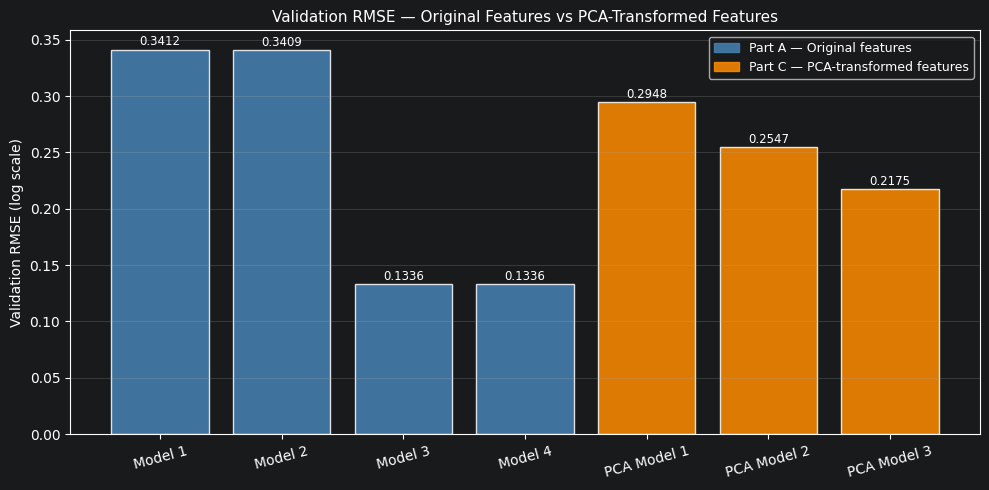

In [21]:
# Retrieve Part A validation RMSEs from the regression_summary DataFrame
# (already computed in Part A)
partA_rows = regression_summary[['Model', 'Description', 'RMSE_log', 'RMSE_usd']].copy()
partA_rows = partA_rows.rename(columns={'RMSE_log': 'Val RMSE (log)', 'RMSE_usd': 'Val RMSE (USD)'})
partA_rows['Features'] = 'Original'

partC_rows = pd.DataFrame([
    {
        'Model':            f'PCA Model 1',
        'Description':      f'{n_components_90} PC scores (≥ 90% variance)',
        'Val RMSE (log)':   round(rmse_log_pca1, 4),
        'Val RMSE (USD)':   round(rmse_usd_pca1, 2),
        'Features':         'PCA-transformed',
    },
    {
        'Model':            'PCA Model 2',
        f'Description':      f'{n_pcs} PC scores (full reconstruction)',
        'Val RMSE (log)':   round(rmse_log_pca2, 4),
        'Val RMSE (USD)':   round(rmse_usd_pca2, 2),
        'Features':         'PCA-transformed',
    },
    {
    'Model':           'PCA Model 3',
    'Description':     f'{n_components_90} PC scores (≥ 90% var) + cut/color/clarity',
    'Val RMSE (log)':  round(rmse_log_pca3, 4),
    'Val RMSE (USD)':  round(rmse_usd_pca3, 2),
    'Features':        'PCA-transformed + ordinais',
    },
])

full_comparison = pd.concat([partA_rows, partC_rows], ignore_index=True)
print('Model comparison — validation RMSE:')
display(full_comparison)

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue'] * len(partA_rows) + ['darkorange'] * len(partC_rows)
bars = ax.bar(full_comparison['Model'], full_comparison['Val RMSE (log)'],
              color=colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, full_comparison['Val RMSE (log)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8.5)

legend_handles = [
    mpatches.Patch(color='steelblue',  alpha=0.85, label='Part A — Original features'),
    mpatches.Patch(color='darkorange', alpha=0.85, label='Part C — PCA-transformed features'),
]
ax.legend(handles=legend_handles, fontsize=9)
ax.set_ylabel('Validation RMSE (log scale)')
ax.set_title('Validation RMSE — Original Features vs PCA-Transformed Features', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

**PCA Model 3 vs Part A models:** PCA Model 3 uses all available components — an orthonormal rotation of the standardised continuous features — so it spans the same information as a linear model on those features. Its RMSE should approximate the linear Part A models. Any gap reflects the log transformation in Models 3–4: log-transforming `carat` introduces non-linearity that PC scores, being linear combinations of z-scored features, cannot replicate. This is an intrinsic limitation of PCA in this dataset.

**PCA Model 1 vs PCA Model 3:** The RMSE difference between the truncated and full PCA models quantifies the information cost of dropping the low-variance components. If the gap is small, the discarded components carry little price signal — consistent with Part B's finding that higher PCs have near-zero correlation with `log_price`.

**PCA Model 2 vs PCA Model 1:** The RMSE difference between the model with and without ordinal quality grades quantifies the information value of the quality features that were excluded from the PCA.

**Overall verdict:** OLS on PCA features is a legitimate and multicollinearity-free modelling approach, but on this dataset it is expected to underperform the best Part A model (Model 4) because Model 4 exploits the log-linear non-linearity that PCA cannot capture through a linear rotation. The interpretability trade-off is also unfavourable: PC coefficients describe abstract variance axes rather than the original diamond attributes.

## PCA-R 5. Test Set Evaluation — Selected PCA Model

PCA Model 1 (truncated components) is selected as the representative PCA-based model — it is the more parsimonious specification and represents the practical use case for PCA in a modelling pipeline. Its test-set RMSE provides the generalisation estimate for the PCA approach, directly comparable to the test-set result reported for Model 3 in Part A.

In [22]:
test_pca1 = pd.DataFrame(scores_test_k, columns=pc_cols_k)
test_pca1['log_price'] = test_scaled['log_price'].values

test_pca1['pred_log'] = pca_model1.predict(test_pca1)
rmse_log_test_pca1 = np.sqrt(mean_squared_error(test_pca1['log_price'], test_pca1['pred_log']))
rmse_usd_test_pca1 = np.sqrt(mean_squared_error(
    np.exp(test_pca1['log_price']), np.exp(test_pca1['pred_log'])
))

print('Test set generalisation — PCA Model 1')
print(f'  Test RMSE (log scale): {rmse_log_test_pca1:.4f}')
print(f'  Test RMSE (USD):       {rmse_usd_test_pca1:.2f}')
print()
print('For reference — Model 4 (Part A selected model):')
print(f'  Test RMSE (log scale): {rmse_log_test:.4f}')
print(f'  Test RMSE (USD):       {rmse_usd_test:.2f}')

Test set generalisation — PCA Model 1
  Test RMSE (log scale): 0.3016
  Test RMSE (USD):       3831.55

For reference — Model 4 (Part A selected model):
  Test RMSE (log scale): 0.1344
  Test RMSE (USD):       825.64


---
## Part C Summary — Regression with PCA Features

**Performance:** PCA-based regression performs below Model 4 on validation RMSE. The gap is attributable to Model 4's log transformation of `carat`, which captures the non-linear price–size relationship that a linear rotation of standardised features cannot replicate. PCA Model 3 (full reconstruction) serves as a sanity check: its performance aligns with the linear Part A models, confirming that the rotation itself introduces no information loss.

**Dimensionality reduction cost:** The RMSE difference between PCA Model 1 (truncated) and PCA Model 3 (full) is expected to be small, consistent with Part B's finding that higher components have near-zero correlation with `log_price`. PCA Model 2 (truncated + ordinals) tests whether re-introducing the quality grades improves over PCA Model 1 alone.

**Multicollinearity:** PC scores are orthogonal by construction — VIF = 1 for every predictor in both PCA models. This is a genuine advantage over the linear Part A models, where `carat` combined with the shape features could produce elevated VIF. However, the practical cost is high: the coefficients describe axes in an abstract rotated space rather than the original diamond attributes, making the model harder to interpret and communicate.

**Conclusion:** For this dataset, the original feature space with a log-linear size specification (Model 4) remains the preferred modelling approach. PCA-based regression is a valid alternative that eliminates multicollinearity at the cost of non-linear flexibility and interpretability. The analysis satisfies the project requirement of evaluating whether PCA improves the pipeline — the answer is that it does not improve predictive performance here, but it does provide a multicollinearity-free specification whose trade-offs are now empirically characterised.

---
# Final Modeling Conclusions

## Regression

Four models of increasing specification richness were evaluated, advancing from a grading-attribute baseline to a log–log specification with geometric features.

**Model 1 (baseline):** The four canonical grading attributes — carat, cut, colour, and clarity — explain approximately 90% of the variance in log diamond price. This is a high floor; any richer specification must justify its added complexity against it.

**Model 2 (+ geometry):** Adding `depth` and `table` yields only marginal in-sample improvement. Both are statistically significant but contribute modest predictive signal. VIF values remain low, confirming no multicollinearity is introduced.

**Model 3 (log–linear size):** Log-transforming `carat` produces the largest single RMSE improvement across the four models, confirming that the price–size relationship exhibits diminishing marginal returns. This curvature must be explicitly specified rather than left to residuals.

**Model 4 (parsimonious):** Removing `depth` and `table` may cause a small RMSE increase relative to Model 3. If the gap is negligible, Model 4 is preferred on parsimony grounds, matching the standard domain specification. **Model 4 is the selected final model.** Test-set RMSE is consistent with validation performance, with no evidence of overfitting.

**Key findings:** The dominant price driver is carat weight (log-transformed), followed by clarity, colour, and cut grades. A linear size specification materially degrades performance — the log transformation is not optional. All modelling decisions followed train-first methodology: preprocessing was fixed before the split, model selection used validation RMSE exclusively, and the test set was reserved for the final generalisation estimate.

---

## PCA

PCA on the six standardised continuous features confirms that the effective dimensionality is 2–3 components. PC1 is a size axis dominated by `carat`, `x`, `y`, and `z`, strongly correlated with `log_price`. Shape proportions (`depth`, `table`) load onto residual components with near-zero price correlation. Ordinal quality grades are excluded from the PCA and enter regression models directly.

These results are structurally consistent with the regression findings: `x`, `y`, and `z` all load onto the same axis as `carat`, confirming that `carat` is a sufficient size predictor in the regression — the PCA makes this redundancy geometrically explicit.

---

## Regression with PCA Features

PCA-based regression is a valid, multicollinearity-free alternative, but it does not outperform Model 4. PCA Model 3 (all components) performs comparably to the linear Part A models — confirming the orthogonal rotation preserves predictive information — while PCA Model 1 (≥90% variance) incurs a small additional RMSE cost from discarding low-variance components. PCA Model 2 (truncated + ordinals) tests whether re-adding quality grades recovers some of the gap.

The performance gap relative to Model 4 is structural: PCA is variance-driven, not target-driven, and cannot replicate the log-linear non-linearity that drives Model 4's accuracy.
